In [1]:
import xarray as xr

file_path = "../data/raw/SSA/SSA.nc"

ds = xr.open_dataset(file_path)

print(ds)

<xarray.Dataset> Size: 878MB
Dimensions:    (time: 381, latitude: 200, longitude: 480)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2025-01-01 2025-01-02 ... 2026-01-16
  * latitude   (latitude) float32 800B 5.062 5.188 5.312 ... 29.69 29.81 29.94
  * longitude  (longitude) float32 2kB 45.06 45.19 45.31 ... 104.7 104.8 104.9
Data variables:
    sla        (time, latitude, longitude) float64 293MB ...
    err_ugosa  (time, latitude, longitude) float64 293MB ...
    vgos       (time, latitude, longitude) float64 293MB ...
Attributes: (12/43)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    time_coverage_durat

In [2]:
print(ds.dims)
print(ds.coords)
print(ds.data_vars)

FrozenMappingWarningOnValuesAccess({'time': 381, 'latitude': 200, 'longitude': 480})
Coordinates:
  * time       (time) datetime64[ns] 3kB 2025-01-01 2025-01-02 ... 2026-01-16
  * latitude   (latitude) float32 800B 5.062 5.188 5.312 ... 29.69 29.81 29.94
  * longitude  (longitude) float32 2kB 45.06 45.19 45.31 ... 104.7 104.8 104.9
Data variables:
    sla        (time, latitude, longitude) float64 293MB ...
    err_ugosa  (time, latitude, longitude) float64 293MB ...
    vgos       (time, latitude, longitude) float64 293MB ...


In [3]:
print(ds)

<xarray.Dataset> Size: 878MB
Dimensions:    (time: 381, latitude: 200, longitude: 480)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2025-01-01 2025-01-02 ... 2026-01-16
  * latitude   (latitude) float32 800B 5.062 5.188 5.312 ... 29.69 29.81 29.94
  * longitude  (longitude) float32 2kB 45.06 45.19 45.31 ... 104.7 104.8 104.9
Data variables:
    sla        (time, latitude, longitude) float64 293MB ...
    err_ugosa  (time, latitude, longitude) float64 293MB ...
    vgos       (time, latitude, longitude) float64 293MB ...
Attributes: (12/43)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    time_coverage_durat

In [4]:
for var in ds.data_vars:
    print("\n==============================")
    print("VARIABLE:", var)
    print("==============================")
    print(ds[var].attrs)


VARIABLE: sla
{'ancillary_variables': 'err_sla', 'comment': 'The sea level anomaly is the sea surface height above mean sea surface; it is referenced to the [1993, 2012] period; see the product user manual for details', 'grid_mapping': 'crs', 'long_name': 'Sea level anomaly', 'standard_name': 'sea_surface_height_above_sea_level', 'units': 'm'}

VARIABLE: err_ugosa
{'comment': 'The formal mapping error represents a purely theoretical mapping error. It mainly traduces errors induced by the constellation sampling capability and consistency with the spatial/temporal scales considered, as described in Le Traon et al (1998) or Ducet et al (2000)', 'grid_mapping': 'crs', 'long_name': 'Formal mapping error on zonal geostrophic velocity anomalies', 'standard_name': 'surface_geostrophic_eastward_sea_water_velocity_assuming_sea_level_for_geoid standard_error', 'units': 'm/s'}

VARIABLE: vgos
{'grid_mapping': 'crs', 'long_name': 'Absolute geostrophic velocity: meridian component', 'standard_name'

In [5]:
for var in ds.data_vars:
    print("\n==============================")
    print("ENCODING:", var)
    print("==============================")
    print(ds[var].encoding)


ENCODING: sla
{'dtype': dtype('int32'), 'zlib': False, 'szip': False, 'zstd': False, 'bzip2': False, 'blosc': False, 'shuffle': False, 'complevel': 0, 'fletcher32': False, 'contiguous': True, 'chunksizes': None, 'source': 'c:\\OceanF\\data\\raw\\SSA\\SSA.nc', 'original_shape': (381, 200, 480), '_FillValue': np.int32(-2147483647), 'scale_factor': np.float64(0.0001), 'coordinates': 'longitude latitude'}

ENCODING: err_ugosa
{'dtype': dtype('int32'), 'zlib': False, 'szip': False, 'zstd': False, 'bzip2': False, 'blosc': False, 'shuffle': False, 'complevel': 0, 'fletcher32': False, 'contiguous': True, 'chunksizes': None, 'source': 'c:\\OceanF\\data\\raw\\SSA\\SSA.nc', 'original_shape': (381, 200, 480), '_FillValue': np.int32(-2147483647), 'scale_factor': np.float64(0.0001), 'coordinates': 'longitude latitude'}

ENCODING: vgos
{'dtype': dtype('int32'), 'zlib': False, 'szip': False, 'zstd': False, 'bzip2': False, 'blosc': False, 'shuffle': False, 'complevel': 0, 'fletcher32': False, 'contigu

In [6]:
for var in ds.data_vars:
    print(
        var,
        "dtype =", ds[var].dtype,
        "min =", float(ds[var].min()),
        "max =", float(ds[var].max()),
        "mean =", float(ds[var].mean()),
        "missing =", int(ds[var].isnull().sum())
    )

sla dtype = float64 min = -0.4575 max = 0.6831 mean = 0.14373931737294798 missing = 18022062
err_ugosa dtype = float64 min = 0.010700000000000001 max = 0.5779000000000001 mean = 0.05924329062110696 missing = 18022062
vgos dtype = float64 min = -2.4585 max = 2.3652 mean = 0.01873896856927163 missing = 18147792


In [7]:
print("Actual first time:", ds.time.values[0])
print("Actual last time:", ds.time.values[-1])

print("Metadata start:", ds.attrs.get("time_coverage_start"))
print("Metadata end:", ds.attrs.get("time_coverage_end"))

Actual first time: 2025-01-01T00:00:00.000000000
Actual last time: 2026-01-16T00:00:00.000000000
Metadata start: 2023-12-30T12:00:00Z
Metadata end: 2023-12-31T12:00:00Z


In [8]:
print(
    "Latitude:",
    float(ds.latitude.min()),
    "to",
    float(ds.latitude.max())
)

print(
    "Longitude:",
    float(ds.longitude.min()),
    "to",
    float(ds.longitude.max())
)

Latitude: 5.0625 to 29.9375
Longitude: 45.0625 to 104.9375


In [9]:
for var in ds.data_vars:
    print("\n================================")
    print("VARIABLE:", var)
    print("================================")
    print("Attributes:")
    print(ds[var].attrs)
    print("\nEncoding:")
    print(ds[var].encoding)


VARIABLE: sla
Attributes:
{'ancillary_variables': 'err_sla', 'comment': 'The sea level anomaly is the sea surface height above mean sea surface; it is referenced to the [1993, 2012] period; see the product user manual for details', 'grid_mapping': 'crs', 'long_name': 'Sea level anomaly', 'standard_name': 'sea_surface_height_above_sea_level', 'units': 'm'}

Encoding:
{'dtype': dtype('int32'), 'zlib': False, 'szip': False, 'zstd': False, 'bzip2': False, 'blosc': False, 'shuffle': False, 'complevel': 0, 'fletcher32': False, 'contiguous': True, 'chunksizes': None, 'source': 'c:\\OceanF\\data\\raw\\SSA\\SSA.nc', 'original_shape': (381, 200, 480), '_FillValue': np.int32(-2147483647), 'scale_factor': np.float64(0.0001), 'coordinates': 'longitude latitude'}

VARIABLE: err_ugosa
Attributes:
{'comment': 'The formal mapping error represents a purely theoretical mapping error. It mainly traduces errors induced by the constellation sampling capability and consistency with the spatial/temporal scal

In [10]:
import xarray as xr

processed_file = "../data/processed/SSA/SSA_processed.nc"

ds_ssa = xr.open_dataset(processed_file)

print(ds_ssa)

<xarray.Dataset> Size: 439MB
Dimensions:    (time: 381, latitude: 200, longitude: 480)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2025-01-01 2025-01-02 ... 2026-01-16
  * latitude   (latitude) float32 800B 5.062 5.188 5.312 ... 29.69 29.81 29.94
  * longitude  (longitude) float32 2kB 45.06 45.19 45.31 ... 104.7 104.8 104.9
Data variables:
    sla        (time, latitude, longitude) float32 146MB ...
    err_ugosa  (time, latitude, longitude) float32 146MB ...
    vgos       (time, latitude, longitude) float32 146MB ...
Attributes: (12/43)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    time_coverage_durat

In [11]:
for var in ["sla", "err_ugosa", "vgos"]:
    data = ds_ssa[var]

    print("\n==============================")
    print(var)
    print("==============================")
    print("dtype:", data.dtype)
    print("units:", data.attrs.get("units"))
    print("minimum:", float(data.min()))
    print("maximum:", float(data.max()))
    print("mean:", float(data.mean()))
    print("missing:", int(data.isnull().sum()))


sla
dtype: float32
units: m
minimum: -0.45750001072883606
maximum: 0.6830999851226807
mean: 0.14373932778835297
missing: 18022062

err_ugosa
dtype: float32
units: m/s
minimum: 0.010700000450015068
maximum: 0.5778999924659729
mean: 0.05924328416585922
missing: 18022062

vgos
dtype: float32
units: m/s
minimum: -2.4584999084472656
maximum: 2.3652000427246094
mean: 0.018738970160484314
missing: 18147792


In [12]:
print("Start:", ds_ssa.time.values[0])
print("End:", ds_ssa.time.values[-1])

Start: 2025-01-01T00:00:00.000000000
End: 2026-01-16T00:00:00.000000000


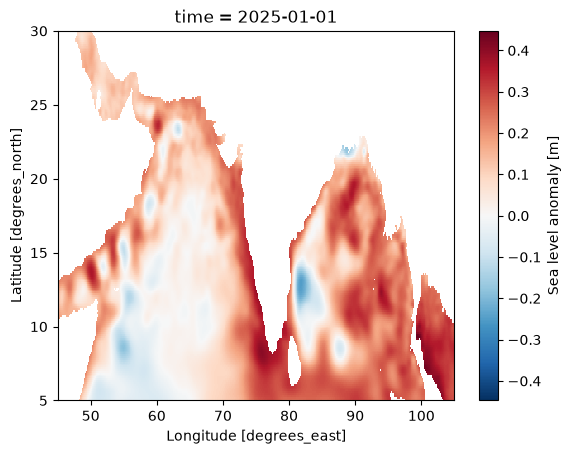

In [13]:
ds_ssa["sla"].isel(time=0).plot()

import matplotlib.pyplot as plt
plt.show()

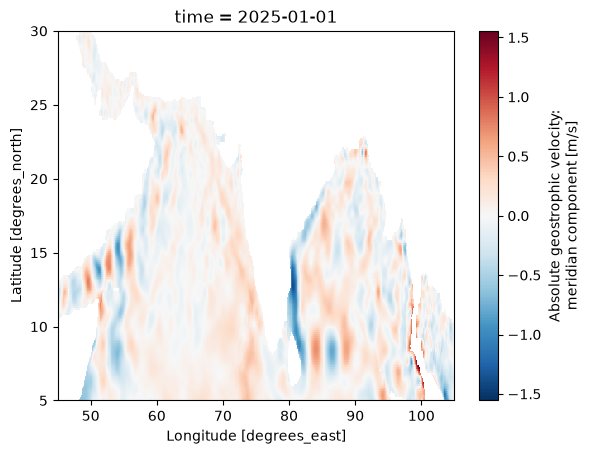

In [14]:
ds_ssa["vgos"].isel(time=0).plot()

plt.show()

In [15]:
ds_ssa = xr.open_dataset("../data/processed/SSA/SSA_processed.nc")


In [16]:
ds_ssa.close()